# M0 — Configuration Scaffold for the `robust.rt` Backend

This notebook is the explainer for **Milestone M0** of the `rob_rt` integration:
wiring BING's fitters up to retrieve-or-bust's `robust.rt` forward model as a new,
user-selectable RT backend.

M0 builds **configuration only** — no physics, no fitter changes yet:

1. `bing` takes `retrieve-or-bust` as a real runtime dependency.
2. `bing.rt.defs.rt_dict_from_p` grows three new keys (`rt_backend`, `fit_Bp`,
   `Bp_value`), and a new `validate_rt_dict` checks them at fit setup.
3. `bing.rt.geometry.ObsGeometry` carries fixed, per-pixel viewing/illumination
   geometry that the robust backend needs and BING never had.

See [`docs/design/rob_rt_design.md`](../../docs/design/rob_rt_design.md) for the
full design, [`docs/coding_plan/rob_rt_coding_plan.md`](../../docs/coding_plan/rob_rt_coding_plan.md)
for the milestone plan, and
[`claude_prompts/RT/rob_rt_prompt_1.md`](../../claude_prompts/RT/rob_rt_prompt_1.md)
for the task-by-task execution log this notebook accompanies.

## Where M0 sits in the dispatch

The actual *dispatch* — routing a fit through the Gordon path or the robust
path — is **M2**, not M0. M0 only builds the configuration surface that M2 will
read. The diagram below shows the whole picture so M0's pieces are legible in
context; the robust-backend half (right branch) is not wired up yet.

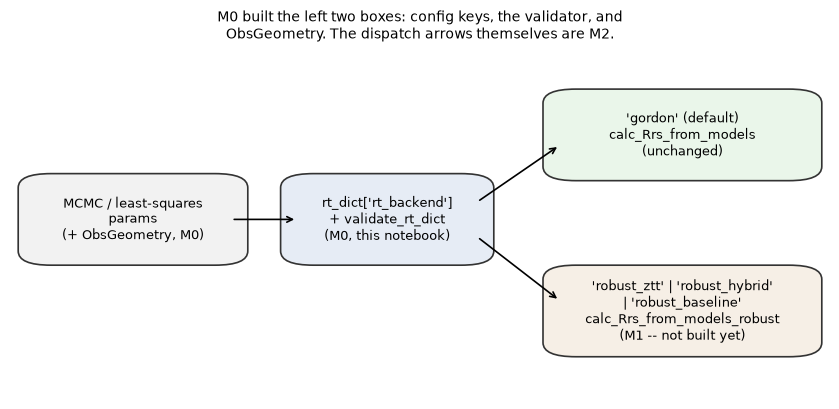

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

def box(xy, w, h, text, fc='#f2f2f2', ec='#333333', fontsize=9):
    r = mpatches.FancyBboxPatch(xy, w, h,
                                 boxstyle='round,pad=0.02,rounding_size=0.04',
                                 linewidth=1.2, edgecolor=ec, facecolor=fc)
    ax.add_patch(r)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text,
            ha='center', va='center', fontsize=fontsize)

def arrow(p0, p1):
    ax.annotate('', xy=p1, xytext=p0, arrowprops=dict(arrowstyle='->', lw=1.2))

box((0.03, 0.40), 0.24, 0.22,
    "MCMC / least-squares\nparams\n(+ ObsGeometry, M0)")
box((0.35, 0.40), 0.22, 0.22,
    "rt_dict['rt_backend']\n+ validate_rt_dict\n(M0, this notebook)",
    fc='#e6ecf5')
box((0.67, 0.64), 0.30, 0.22,
    "'gordon' (default)\ncalc_Rrs_from_models\n(unchanged)",
    fc='#eaf6ea')
box((0.67, 0.14), 0.30, 0.22,
    "'robust_ztt' | 'robust_hybrid'\n| 'robust_baseline'\ncalc_Rrs_from_models_robust\n(M1 -- not built yet)",
    fc='#f6efe6')

arrow((0.27, 0.51), (0.35, 0.51))
arrow((0.57, 0.56), (0.67, 0.72))
arrow((0.57, 0.46), (0.67, 0.28))

ax.set_title("M0 built the left two boxes: config keys, the validator, and\n"
             "ObsGeometry. The dispatch arrows themselves are M2.",
             fontsize=10)
plt.tight_layout()
plt.show()

## 1. `rt_dict['rt_backend']` — one combined selector

`robust.rt` offers three fidelity levels (`ztt`, `hybrid`, `baseline`) on top of
BING's existing Gordon path, so in principle a fit needs *two* choices: which
backend, and (if robust) which mode. `rt_dict_from_p` instead exposes **one**
combined key:

```python
rt_dict['rt_backend']  # 'gordon' | 'robust_ztt' | 'robust_hybrid' | 'robust_baseline'
```

Why one key and not two (`rt_backend` + `robust_mode`): it makes illegal states
unrepresentable (no `robust_mode` dangling while `rt_backend='gordon'`), and it
keeps `rt_dict` a flat dict of scalars, matching every other flag it already
carries. A missing key defaults to `'gordon'` — every legacy/saved `rt_dict`
keeps working with zero changes.

In [2]:
from bing.parameters import p_ntuple
from bing.rt import defs as rt_defs

# A p object with no rt_backend/fit_Bp/Bp_value attributes at all -- the
# "legacy" case every existing caller is in today.
p = p_ntuple.gen(model_names=['ExpBricaud', 'Pow'])
rt_dict = rt_defs.rt_dict_from_p(p)
{k: rt_dict[k] for k in ('rt_backend', 'fit_Bp', 'Bp_value')}

{'rt_backend': 'gordon', 'fit_Bp': False, 'Bp_value': 0.01}

In [3]:
from collections import namedtuple

# A p object that does set the new fields.
Custom = namedtuple('Custom', ['model_names', 'rt_backend', 'fit_Bp', 'Bp_value'])
p_custom = Custom(model_names=['ExpBricaud', 'Pow'], rt_backend='robust_hybrid',
                   fit_Bp=True, Bp_value=0.02)
rt_dict_custom = rt_defs.rt_dict_from_p(p_custom)
{k: rt_dict_custom[k] for k in ('rt_backend', 'fit_Bp', 'Bp_value')}

{'rt_backend': 'robust_hybrid', 'fit_Bp': True, 'Bp_value': 0.02}

## 2. `validate_rt_dict` — what it rejects, and why

`validate_rt_dict(rt_dict, models=None, geom=None)` runs once at fit setup (M2
will call it before sampling starts, never per forward-model call) and raises
`ValueError` on four illegal configurations:

| # | Illegal configuration | Why |
|---|---|---|
| i | `rt_backend` not one of the four valid values | typo guard |
| ii | `fit_Bp=True` with `rt_backend='gordon'` | Gordon has no phase-function input to fit |
| iii | a robust backend with `geom is None` | `theta_s` is required, never silently defaulted (Q&A/Coding item 4) |
| iv | `rt_backend='robust_hybrid'` with any wavelength outside [350, 750] nm | outside the emulator's training range |

`models`/`geom` are optional: omitting either just **skips** the check that
needs it, rather than raising — useful for probing one check in isolation, as
below. Note `robust_ztt`/`robust_baseline` are *not* grid-restricted (only the
learned emulator, `robust_hybrid`, is) — see `docs/design/rob_rt_design.md` §4.

In [4]:
import numpy as np


class FakeModel:
    # A stand-in for an a-model/bb-model -- validate_rt_dict only reads .wave.
    def __init__(self, wave):
        self.wave = np.asarray(wave)


def try_validate(label, **kwargs):
    try:
        rt_defs.validate_rt_dict(**kwargs)
        print(f"{label}: OK, no error")
    except ValueError as e:
        print(f"{label}: ValueError -- {e}")


try_validate("(i) unknown backend",
             rt_dict={'rt_backend': 'not_a_real_backend'})

try_validate("(ii) fit_Bp=True + rt_backend='gordon'",
             rt_dict={'rt_backend': 'gordon', 'fit_Bp': True})

try_validate("(iii) robust backend, geom=None",
             rt_dict={'rt_backend': 'robust_hybrid'}, geom=None)

try_validate("(iv) robust_hybrid, grid reaches 760 nm",
             rt_dict={'rt_backend': 'robust_hybrid'},
             models=[FakeModel(np.linspace(400., 760., 37)), None],
             geom=object())

try_validate("robust_ztt, same wide grid -- ztt is grid-agnostic",
             rt_dict={'rt_backend': 'robust_ztt'},
             models=[FakeModel(np.linspace(400., 760., 37)), None],
             geom=object())

try_validate("legal robust_hybrid fit (350-700 nm, geom given)",
             rt_dict={'rt_backend': 'robust_hybrid'},
             models=[FakeModel(np.linspace(350., 700., 71)), None],
             geom=object())

(i) unknown backend: ValueError -- rt_dict['rt_backend']='not_a_real_backend' is not one of ('gordon', 'robust_ztt', 'robust_hybrid', 'robust_baseline')
(ii) fit_Bp=True + rt_backend='gordon': ValueError -- rt_dict['fit_Bp']=True requires a robust backend -- the Gordon backend has no phase-function input (rt_dict['rt_backend']='gordon')
(iii) robust backend, geom=None: ValueError -- rt_dict['rt_backend']='robust_hybrid' requires geometry -- pass an ObsGeometry via geom= (theta_s is never silently defaulted; claude_prompts/rob_rt.md Q&A/Coding item 4)
(iv) robust_hybrid, grid reaches 760 nm: ValueError -- rt_dict['rt_backend']='robust_hybrid' requires all wavelengths within [350.0, 750.0] nm (the emulator's training range); got range [400.0, 760.0]
robust_ztt, same wide grid -- ztt is grid-agnostic: OK, no error
legal robust_hybrid fit (350-700 nm, geom given): OK, no error


## 3. `ObsGeometry` — fixed, non-fit per-pixel geometry

`robust.rt` needs explicit BRDF geometry (`theta_s`, `theta_v`, `dphi`); BING
never tracked it -- it was baked into Gordon's fixed mean-cosine constants.
`ObsGeometry` is the new container:

* `theta_s` is **required, no default** -- omitting it is a `TypeError`, never a
  silent guess (Q&A/Coding item 4).
* `theta_v`/`dphi` default to nadir viewing (`0.0`, `0.0`).
* It is **frozen** and carries no fit machinery: geometry is known/measured
  scene data, not something MCMC should search over (Q&A/Design items 3, 11, 14).
* `to_robust(Ed=None)` maps it onto `robust.rt.types.Geometry` -- a direct,
  one-to-one keyword pass-through, since the field names already match.

In [5]:
from bing.rt.geometry import ObsGeometry

# Nadir case: only theta_s known.
g = ObsGeometry(theta_s=30.)
rg = g.to_robust()
print("ObsGeometry:", g)
print("-> robust Geometry:", rg)
print()

# Non-nadir, with wind and an Ed pass-through pair (the M4 seam -- not stored
# on ObsGeometry itself).
g2 = ObsGeometry(theta_s=45., theta_v=10., dphi=90., wind=5.)
ed_pair = (np.array([400., 500.]), np.array([1.0, 0.9]))
rg2 = g2.to_robust(Ed=ed_pair)
print("ObsGeometry:", g2)
print("-> robust Geometry:", rg2)
print("Ed stored on ObsGeometry?", hasattr(g2, 'Ed'))
print()

# theta_s is required.
try:
    ObsGeometry()
except TypeError as e:
    print("ObsGeometry() with no theta_s ->", type(e).__name__, "--", e)

# Frozen.
try:
    g.theta_s = 99.
except Exception as e:
    print("g.theta_s = 99. ->", type(e).__name__, "--", e)

ObsGeometry: ObsGeometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None)
-> robust Geometry: Geometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None, Ed=None)

ObsGeometry: ObsGeometry(theta_s=45.0, theta_v=10.0, dphi=90.0, wind=5.0)
-> robust Geometry: Geometry(theta_s=45.0, theta_v=10.0, dphi=90.0, wind=5.0, Ed=(array([400., 500.]), array([1. , 0.9])))
Ed stored on ObsGeometry? False

ObsGeometry() with no theta_s -> TypeError -- ObsGeometry.__init__() missing 1 required positional argument: 'theta_s'
g.theta_s = 99. -> FrozenInstanceError -- cannot assign to field 'theta_s'


## What's next

M0 is configuration only -- nothing above is wired into a real fit yet.
**M1** (`claude_prompts/RT/rob_rt_prompt_2.md`) builds the actual forward
adapter, `calc_Rrs_from_models_robust`, that these `rt_dict` keys and
`ObsGeometry` instances will feed into. **M2** is where `rt_dict['rt_backend']`
actually starts dispatching a real fit down one path or the other.